# 3. Try the chatbots: identification, assessment, report & guardrail

One notebook, one photo, three agents in sequence -- each stage **saves
its result to plain variables** that the next stage reads. You never
retype a species name: Part 2 reads the `SPECIES`/`ANIMAL_GROUP`/...
variables Part 1 just set, and Part 3 continues the same conversation
object Part 2 built. Want to test something different mid-way? Edit the
variables (or the `chat` object) in place and re-run from there --
nothing earlier needs to change.

| Part | Agent | What it decides |
|---|---|---|
| 1 | Identification | What animal is this? (asks up to 5 of its own questions) |
| 2 | Assessment | What's wrong with it, and what should happen? (up to 5 more) |
| 3 | Report + guardrail | The report sent to responders, checked for invented claims and unsafe advice |

Everything below has an **offline mode** (default, no credentials) using
scripted replies, and a **live mode** that calls the real model.

In [23]:
# Auto-apply backend code edits without restarting the kernel: after you
# (or Claude) edit a .py file under backend/lifejacket/, the next cell you
# run picks up the change automatically -- no "Restart Kernel" needed.
#
# This does NOT cover prompts/*.md (those are cached by load_prompt(), not
# reloaded as Python modules) -- call clear_prompt_cache() for those, or use
# the cell further down that already does this after a prompt edit.
%load_ext autoreload
%autoreload 2

# Make the backend importable from notebooks/.
import sys, pathlib
REPO_ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'backend'))

from lifejacket.chatbot.playground import ChatPlayground
from lifejacket.llm.fake import ScriptedLLMClient
from lifejacket.config import settings

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Choose a mode

| Mode | What answers | Needs | Use it to |
|---|---|---|---|
| `"offline"` | Hand-written scripted replies | Nothing | Learn the flow, test edge cases, read the prompts |
| `"live"` | Real Gemini on Vertex AI | `gcloud auth application-default login` + a photo | Judge the agent's actual behaviour |

Offline mode still runs **all the real code** -- prompt rendering, taxonomy,
stopping rules, severity scoring. Only the model's replies are canned.

Offline scenarios: `"sea_lion"` (obvious species, no questions),
`"seal"` (one question settles it), `"dolphin"` (species can't be told
apart, so it settles on *oceanic dolphins* with both probabilities),
`"raccoon"` (not a marine animal at all -- see Part 1's note on that).

In [24]:
MODE = "live"          # "offline" or "live"
# SCENARIO = "dolphin"      # offline only: "sea_lion", "seal", "dolphin", "raccoon"

# Live mode only: EVERY image file dropped into notebooks/sample_photos/ is
# used as a photo of the SAME animal/incident (the folder is gitignored, so
# nothing you put there gets committed). Add as many as you like -- a side
# view, a close-up, a shot from further back -- the agent sees all of them
# together, the way several reporter photos of one animal would.
PHOTO_DIR = REPO_ROOT / "notebooks" / "sample_photos"
PHOTO_EXTENSIONS = {".jpg", ".jpeg", ".png", ".heic", ".webp"}
PHOTOS = sorted(p for p in PHOTO_DIR.glob("*") if p.suffix.lower() in PHOTO_EXTENSIONS)

# Where the animal is. Drives tide, weather, species range, and routing.
LATITUDE, LONGITUDE = 36.8044, -121.7869   # Moss Landing, CA


def make_client():
    """A fresh client per conversation: scripted offline, real Vertex AI live."""
    return ScriptedLLMClient.scenario(SCENARIO) if MODE == "offline" else None


def photos():
    return [] if MODE == "offline" else PHOTOS


if MODE == "live":
    import google.auth
    _, project = google.auth.default()   # raises if you have not logged in
    print("Vertex AI credentials found for project:", project)
    assert PHOTOS, f"No photos found in {PHOTO_DIR} -- add at least one and re-run this cell."
    print(f"Using {len(PHOTOS)} photo(s): {', '.join(p.name for p in PHOTOS)}")
else:
    print(f"Offline mode, scenario: {SCENARIO}")

Vertex AI credentials found for project: None
Using 1 photo(s): images_362588731.jpg


## Check your photos before running

**All photos above go to the agent in one call, and it assumes they show
the same animal** -- there is no code anywhere that checks this for you.
If you dropped in photos of two different animals by mistake, this cell
lets you catch it visually before wasting a turn on a confused answer.

If something here looks wrong, delete the stray photo from
`sample_photos/` and re-run the setup cell above.

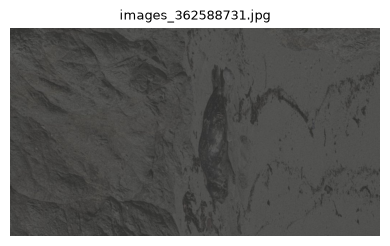

In [25]:
if MODE == "live" and PHOTOS:
    import matplotlib.pyplot as plt
    from PIL import Image

    fig, axes = plt.subplots(1, len(PHOTOS), figsize=(4 * len(PHOTOS), 4))
    axes = [axes] if len(PHOTOS) == 1 else list(axes)

    for ax, path in zip(axes, PHOTOS):
        ax.set_title(path.name, fontsize=9)
        ax.axis('off')
        try:
            ax.imshow(Image.open(path))
        except Exception:
            # Pillow cannot preview every format (notably some HEIC files)
            # without an extra plugin -- the agent still receives the raw
            # bytes fine, this is a notebook-only limitation.
            ax.text(0.5, 0.5, f'(no preview for {path.suffix})', ha='center', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
elif MODE == "live":
    print(f"No photos in {PHOTO_DIR} yet.")
else:
    print("Nothing to preview -- offline mode uses scripted replies, not real photos.")

---
# Part 1: Identification

Looks at the photo and works out **what the animal is**, asking its own
questions. There is no script: each question is picked for *this* photo,
to separate *its* current top candidates.

**It stops asking when the first of these happens:**

| # | Condition | Example |
|---|---|---|
| 1 | Confident (>= 0.90) at **species or genus** level | "California sea lion, 0.94" after 0 questions |
| 2 | **5 questions** used | best answer so far, marked uncertain |
| 3 | Agent says **no question can separate** the remaining species | common vs bottlenose dolphin from 50 yards |
| 4 | Agent tries to ask about a feature it **already asked about** | |

In case 3 the answer may be a **family**, e.g. *oceanic dolphins 0.94*, with
the per-species probabilities (common 0.50, bottlenose 0.44) kept alongside.
That is fine for dispatch: routing is by animal group, and responders confirm
the species on the beach. It can also be a non-marine group entirely --
the `raccoon` scenario shows `TERRESTRIAL`, which Part 2 still handles
correctly (just with no responder available from this marine-only
directory; see `README.md`'s Known limitations).

**Where the code is**

- Agent: [`backend/lifejacket/agents/identification.py`](../backend/lifejacket/agents/identification.py)
- Prompt: [`prompts/identification/identify_species.md`](../prompts/identification/identify_species.md)
- Pooling species into genus/family: [`backend/lifejacket/taxonomy.py`](../backend/lifejacket/taxonomy.py)
- When to stop asking: [`backend/lifejacket/chatbot/session.py`](../backend/lifejacket/chatbot/session.py) -> `identification_stop_reason`

In [26]:
id_chat = ChatPlayground.identification_only(
    photos=photos(), latitude=LATITUDE, longitude=LONGITUDE, client=make_client()
)

AGENT: A brighter photo showing more detail. Could you send another photo? Please stay where you are -- do not move closer to the animal.
       (A brighter photo showing more detail.)



## Answer it

Edit the text and run the cell. The options are shortcuts for tapping; any
text works, and the agent reads it in context. Run the cell again for each
new question. When it prints `-- done`, identification has stopped.

In [ ]:
id_chat.answer("long beak")

Prefer typing in a box? Uncomment and run this instead -- enter `q` to stop.

In [27]:
id_chat.interactive()

YOU:   i cant take another photo
AGENT: Can you see small flaps over its ears, or just small holes?
       options: ear flaps | just holes | not sure
       (Best answer so far is California sea lion at 0.30; asking question 1 of 5.)

YOU:   just holes
AGENT: Roughly how long is it, compared to a person lying down?
       options: shorter | about the same | longer | not sure
       (Best answer so far is True seals at 0.90; asking question 2 of 5.)

YOU:   about the same
AGENT: Can you describe its face?
       options: Short, dog-like snout | Longer, more bulbous snout | Not sure
       (Best answer so far is Harbor seal at 0.70; asking question 3 of 5.)

YOU:   Not sure
AGENT: Does it have a short, dog-like snout, or a broader, more rounded snout?
       options: short, dog-like | broader, rounded | not sure
       (Best answer so far is True seals at 0.90; asking question 4 of 5.)

YOU:   broader, rounded
AGENT: Can you see any spots or patterns on its fur, or is it mostly a solid c

## What did it conclude, and why did it stop?

In [28]:
id_chat.show_identification()

------------------------------------------------------------------------
IDENTIFICATION
------------------------------------------------------------------------
species                     genus         family            prob
Harbor seal                 Phoca         Phocidae          0.90
Northern elephant seal      Mirounga      Phocidae          0.05

Resolved as : Harbor seal (Phoca vitulina), identified to species level, 0.90 (confident)
Group       : pinniped (this is what routes dispatch)
Questions   : 5 of 5 used
Stopped     : Confident at species level: Harbor seal (0.90).
Reasoning   : Ear holes, body length similar to a person, broad rounded snout, and spots or patterns on fur.


Read the table bottom-up: the agent gave per-species probabilities; the
system pooled them by genus and family and picked the **finest rank that
clears the threshold**. The agent never chooses the rank itself.

In [29]:
id_chat.transcript()

YOU    i cant take another photo
AGENT  Can you see small flaps over its ears, or just small holes?
YOU    just holes
AGENT  Roughly how long is it, compared to a person lying down?
YOU    about the same
AGENT  Can you describe its face?
YOU    Not sure
AGENT  Does it have a short, dog-like snout, or a broader, more rounded snout?
YOU    broader, rounded
AGENT  Can you see any spots or patterns on its fur, or is it mostly a solid color?
YOU    spots or patterns


## What did the model actually see?

The exact prompt sent on the last turn -- location, tide, previous candidates,
the conversation, features already asked about. When an answer looks wrong,
this is the first thing to read.

In [30]:
print(id_chat.last_prompt('identification'))

# Task: identify the animal

You are an expert wildlife taxonomist. You are looking at 1
photo(s) of an animal a member of the public found. Work out what it is, as
specifically as the evidence allows.

There is no script: you choose each question yourself, for **this** photo.
Budget: **0 question(s) remaining**
(5 already asked) -- usually fewer are needed.

## What you know

LOCATION
LOCATION: Moss Landing, Monterey County, California (36.8044, -121.7869), reported via device_gps.
LOCAL TIME: 2026-10-01 19:13 (Thursday)
TIDE: Tide is FALLING, low water in about 2h 23m. The animal will be left further from the water as time passes. Wave height 1.4 m. Sea temperature 17.1 C. (Station: General Fish Company Pier, 0.3 km away.)
WEATHER: overcast, 16 C, wind 8 mph (gusting 10), 0% chance of precipitation, visibility 7.8 miles
RESPONDER CONDITIONS RISK: 0.00 (0 = straightforward, 1.5 = hazardous for responders)

Species ranges are real constraints (a harbour seal in central California is
fa

In [9]:
# The raw JSON it sent back, before any processing.
id_chat.last_response('identification')

{'candidates': [{'common_name': 'Harbor Seal',
   'scientific_name': 'Phoca vitulina',
   'genus': 'Phoca',
   'genus_common_name': 'Hair seals',
   'family': 'Phocidae',
   'family_common_name': 'True seals',
   'confidence': 0.9,
   'animal_group': 'pinniped'},
  {'common_name': 'Northern Elephant Seal',
   'scientific_name': 'Mirounga angustirostris',
   'genus': 'Mirounga',
   'genus_common_name': 'Elephant seals',
   'family': 'Phocidae',
   'family_common_name': 'True seals',
   'confidence': 0.1,
   'animal_group': 'pinniped'}],
 'species_distinguishable': False,
 'reasoning': 'Ear holes, body length, and head/snout shape strongly indicate a Harbor Seal. The image is too dark for further visual identification.',
 'needs_new_photo': True,
 'photo_quality_note': 'A clearer photo showing markings or color.',
 'next_question': '',
 'next_question_rationale': '',
 'next_question_options': [],
 'next_question_feature': ''}

## Save the result, for Part 2

The four variables below are what Part 2 (assessment) reads -- nothing is
retyped. Want to test a **different** species instead? Just edit these
four lines yourself and re-run from here; Part 2's own cells need no
changes.

In [32]:
_top = id_chat.state.identification.top_candidate

# What Part 2 will treat the animal as. display_name is the RESOLVED rank --
# a species ('Harbor seal'), or a genus/family/group name ('Oceanic dolphins')
# when identification settled for something coarser. Passing that through
# (rather than always the top species guess) is what keeps Part 2 honest
# about how specific the identification actually was.
SPECIES = id_chat.state.identification.display_name
SCIENTIFIC_NAME = (
    id_chat.state.identification.resolution.scientific_name
    if id_chat.state.identification.resolution else None
) or (_top.scientific_name if _top else None) or 'unknown'
FAMILY = _top.family if _top else None
ANIMAL_GROUP = id_chat.state.identification.animal_group.value
CONFIDENCE = id_chat.state.identification.confidence

print('Saved for Part 2:')
print(f'  SPECIES         = {SPECIES!r}')
print(f'  SCIENTIFIC_NAME = {SCIENTIFIC_NAME!r}')
print(f'  FAMILY          = {FAMILY!r}')
print(f'  ANIMAL_GROUP    = {ANIMAL_GROUP!r}')
print(f'  CONFIDENCE      = {CONFIDENCE:.2f}')

Saved for Part 2:
  SPECIES         = 'Harbor seal'
  SCIENTIFIC_NAME = 'Phoca vitulina'
  FAMILY          = 'Phocidae'
  ANIMAL_GROUP    = 'pinniped'
  CONFIDENCE      = 0.90


---
# Part 2: Assessment

Works out **what is wrong with the animal** and **what should happen**,
using the `SPECIES`/`ANIMAL_GROUP`/... variables Part 1 just saved -- no
species typed in here. It asks up to 5 questions of its own, only ones
whose answer would change the recommendation.

It reports *observations*: wound, bleeding, entanglement, mobility, people
or dogs nearby. It does **not** decide how urgent the case is. Severity is
computed afterwards in plain Python from those observations, with weights
in [`config/scoring.json`](../config/scoring.json), so a coordinator can see
exactly which flags drove the rating.

**Where the code is**

- Agent: [`backend/lifejacket/agents/assessment.py`](../backend/lifejacket/agents/assessment.py)
- Prompt: [`prompts/assessment/assess_situation.md`](../prompts/assessment/assess_situation.md)
- Severity: [`backend/lifejacket/dispatch/severity.py`](../backend/lifejacket/dispatch/severity.py)
- Tide and weather: [`backend/lifejacket/context/`](../backend/lifejacket/context/)

In [33]:
assess_chat = ChatPlayground.assessment_only(
    species=SPECIES, scientific_name=SCIENTIFIC_NAME, family=FAMILY,
    animal_group=ANIMAL_GROUP, confidence=CONFIDENCE,
    photos=photos(), latitude=LATITUDE, longitude=LONGITUDE, client=make_client(),
)

AGENT: Can you describe any movement, breathing, or visible injuries on the seal?
       (Assessment is not yet confident; asking question 1 of 5.)



In [ ]:
print(assess_chat.environment_summary())

## Answer its questions

Edit and re-run for each question. It prints `-- done` when it has enough
to make a recommendation (it stops before writing the report).

In [ ]:
assess_chat.answer("yes, green netting around its neck")

In [ ]:
assess_chat.interactive()   # or type answers in a box; q to stop

YOU:   no movement, some breathing?
AGENT: Can you see any visible injuries, such as cuts, open wounds, or anything wrapped around the seal?
       (Assessment is not yet confident; asking question 2 of 5.)

YOU:   has some cuts, and bleeding
AGENT: Can you see if there are any people or dogs nearby, or if the seal is close to a road?
       options: yes, people are nearby | yes, dogs are nearby | yes, it's near a road | no, none of those are nearby
       (Assessment is not yet confident; asking question 3 of 5.)

YOU:   no, none of those are nearby
AGENT: Can you describe the seal's breathing? Is it shallow, deep, or labored?
       (Assessment is not yet confident; asking question 4 of 5.)



## Observations and the severity they produce

In [35]:
assess_chat.show_assessment()

------------------------------------------------------------------------
ASSESSMENT
------------------------------------------------------------------------
Flags set   : injury_present, wound, bleeding, risk_of_being_stranded_further
Mobility    : immobile
Summary     : Seal has cuts and is bleeding, with no visible movement.

SEVERITY    : CRITICAL  (score 5.3, confidence 0.92)
   +1.4  injury
   +1.3  wound
   +1.4  bleeding
   +1.2  mobility_concern
   - An actively bleeding wound is critical.
   - Falling tide with an animal that cannot reach the water on its own: the distance to the sea is increasing and heat stress risk rises.

Action      : A permitted rescue team needs to assess the seal's injuries and immobility.
   * Keep a safe distance from the seal.
   * Do not approach the animal.
   * Keep any pets away from the area.
   * Observe from afar if it is safe to do so.
Questions   : 4 of 5 used


The `+points` lines are the additive score. Some conditions -- entanglement,
a bleeding wound, breathing trouble, an unresponsive animal, an immobile
cetacean -- are **hard rules** that force CRITICAL regardless of the score,
because averaging them away would be dangerous: entanglement alone only
scores 1.4, below the 3.0 "respond" line.

In [14]:
print(assess_chat.last_prompt('assessment'))

# Task: assess the situation

You are an expert wildlife veterinarian. The animal has been identified.
Determine **what is wrong with it** and **what should happen next**.

You may ask the reporter up to **1 more question(s)**
(4 already asked).

## The animal

- Species: **Harbor Seal** (Phoca vitulina)
- Identification confidence: 0.90
- Animal group: pinniped
- Identification detail: Harbor Seal (Phoca vitulina), identified to species level, 0.90 (confident)

If only identified to genus or family level, give advice correct for
**every** species listed -- do not try to re-identify it here.

What this group needs you to know:
Seals and sea lions rest on land normally. Hauling out is NOT by itself a sign of distress, and healthy pups are often left alone by a foraging mother for a day or more. Moving a healthy pup orphans it. Look for actual injury, severe emaciation, entanglement, or a pup clearly too young to be weaned.

## The scene

LOCATION: Moss Landing, Monterey County, Californ

---
# Part 3: Report & guardrail

Continues `assess_chat` straight through to the end -- same photo, same
species, same answers, nothing re-entered. Two more agents run:

1. **Report agent** -- distils everything into the short report a rescue
   coordinator reads on their phone. The headline must stand on its own.
2. **Guardrail agent** -- a second model checks that report against the
   source data for **invented claims** and **unsafe advice** (pushing a
   dolphin back to sea, washing an oiled bird...). A report that fails is
   *held for a human*, never silently dropped.

Then responders are ranked for a coordinator to approve. Nothing is
dispatched automatically.

**Where the code is**

- [`backend/lifejacket/agents/report.py`](../backend/lifejacket/agents/report.py) and [`prompts/report/write_report.md`](../prompts/report/write_report.md)
- [`backend/lifejacket/agents/guardrail.py`](../backend/lifejacket/agents/guardrail.py) and [`prompts/report/guardrail_review.md`](../prompts/report/guardrail_review.md)
- The full flow: [`backend/lifejacket/services/pipeline.py`](../backend/lifejacket/services/pipeline.py)

In [15]:
assess_chat.finish()

Incident INC_6a02ea44 held for review: grounded=False safe=True


AGENT: Maintain a distance of at least 50 yards (45 meters) from the seal.
       What you can do now:
       • Keep a safe distance from the seal.
       • Do not approach or touch the animal.
       • Keep pets and other people away from the area.
       • Observe from a distance if it is safe to do so.
       Your report has been sent to the rescue coordinators for this area. You can follow its progress on the map.
-- done: Identification and assessment complete; writing the report.



TurnResult(message='Maintain a distance of at least 50 yards (45 meters) from the seal.\nWhat you can do now:\n• Keep a safe distance from the seal.\n• Do not approach or touch the animal.\n• Keep pets and other people away from the area.\n• Observe from a distance if it is safe to do so.\nYour report has been sent to the rescue coordinators for this area. You can follow its progress on the map.', options=[], awaiting_reply=False, complete=True, action=<StepAction.FINALISE: 'finalise'>, reason='Identification and assessment complete; writing the report.')

## The report

In [16]:
assess_chat.show_report()

------------------------------------------------------------------------
INCIDENT REPORT
------------------------------------------------------------------------
Harbor Seal, Moss Landing, unresponsive, falling tide, limited daylight

Immobile, unresponsive Harbor Seal with fresh cuts reported at Moss Landing, Monterey County. Tide is falling, increasing distance to water. Sunset in 0.2 hours.

Actions:
  1. Permitted rescue team to assess and intervene.
  2. Prioritize immediate response due to falling tide and limited daylight.

Equipment:
  - Transport crate
  - First aid kit
  - Headlamps/lighting

Hazards:
  - Falling tide
  - Limited daylight
  - Wild animal bite risk

Not established:
  - Breathing depth/labor
  - Specific nature of cuts

GUARDRAIL   : HELD FOR HUMAN REVIEW
   unsupported_claims: Transport crate
   unsupported_claims: First aid kit
   unsupported_claims: Headlamps/lighting
   unsupported_claims: Wild animal bite risk
   missing_critical_content: abnormal_posture

If identification stopped at genus or family level, the summary should say
so and give the species probabilities -- see Part 1 above.

In [17]:
print(assess_chat.last_prompt('report'))

# Task: write the incident report

You are an experienced wildlife rescue dispatcher. Write the report that goes
out to rescue organisations and volunteers.

**Your reader** is a stranding-network coordinator or trained volunteer,
deciding in about fifteen seconds on their phone whether to act. They have
handled hundreds of these.

Write dense and factual: no preamble, no reassurance, no restating what is
already in the structured fields. Assume competence.

## The incident

- Animal: **Harbor Seal** (Phoca vitulina), identification confidence 0.90
- Animal group: pinniped
- Identification detail: Harbor Seal (Phoca vitulina), identified to species level, 0.90 (confident)
- Location: **Moss Landing, Monterey County, California** — 36.80440, -121.78690
- Triage: **critical** (score 4.80)
- Volunteer may attend: no -- professional team required
- Recommended action: A permitted rescue team needs to assess and potentially intervene.
- Time sensitivity: 3.0 hours

Why it was triaged this w

## What the coordinator's console receives

Everything above, as stored. The responder console renders this; the
reporter's app only sees the closing message.

In [18]:
import json
print(json.dumps(assess_chat.incident.model_dump(mode='json', exclude={'environment'}), indent=2)[:4000])

{
  "incident_id": "INC_6a02ea44",
  "status": "awaiting_dispatch",
  "created_at": "2026-10-01T18:35:37.234021",
  "updated_at": "2026-10-01T18:35:37.234055",
  "reporter_id": null,
  "reporter_phone": null,
  "location": {
    "latitude": 36.8044,
    "longitude": -121.7869,
    "place_name": "Moss Landing, Monterey County, California",
    "source": "device_gps",
    "accuracy_meters": null
  },
  "photo_ids": [],
  "identification": {
    "candidates": [
      {
        "common_name": "Harbor Seal",
        "scientific_name": "Phoca vitulina",
        "confidence": 0.9,
        "animal_group": "pinniped",
        "genus": null,
        "genus_common_name": null,
        "family": "Phocidae",
        "family_common_name": null
      }
    ],
    "resolution": {
      "rank": "species",
      "name": "Harbor Seal",
      "scientific_name": "Phoca vitulina",
      "confidence": 0.9,
      "animal_group": "pinniped",
      "meets_threshold": true,
      "members": [
        {
         

---
# Experiments

## Identification: A. The pooling calculator

Type in probabilities and see what the system would conclude. No model
involved -- this is `taxonomy.resolve_taxon`, the same function the agent's
output goes through.

In [ ]:
from lifejacket.models.schemas import AnimalGroup, SpeciesCandidate
from lifejacket.taxonomy import describe_resolution, resolve_taxon

def candidate(name, scientific, p, family, family_common, group='cetacean'):
    return SpeciesCandidate(common_name=name, scientific_name=scientific, confidence=p,
                            family=family, family_common_name=family_common,
                            animal_group=AnimalGroup(group))

# Edit these numbers.
candidates = [
    candidate('Common dolphin',     'Delphinus delphis',  0.50, 'Delphinidae', 'oceanic dolphins'),
    candidate('Bottlenose dolphin', 'Tursiops truncatus', 0.44, 'Delphinidae', 'oceanic dolphins'),
    candidate('Harbour porpoise',   'Phocoena phocoena',  0.03, 'Phocoenidae', 'porpoises'),
]

print(describe_resolution(resolve_taxon(candidates, settings.identification_confidence_threshold)))

Try: raise common dolphin to 0.92 (species level). Drop bottlenose to 0.30
(nothing reaches 0.90 at family, so it falls back to the animal group). Make
them sum past 1.0 (they get rescaled).

## Identification: B. Change when it may stop

By default only **species** and **genus** let the chatbot stop early. Family
is held back because pairs like harbour seal / elephant seal pool to 0.90
for "true seals" -- but one question about size usually settles which.

Run the `seal` scenario both ways and compare the question count.

In [ ]:
def run_seal():
    c = ChatPlayground.identification_only(
        client=ScriptedLLMClient.scenario('seal'), live_context=False, verbose=False
    )
    if not c.done:
        c.answer('shorter')
    r = c.state.identification.resolution
    return f'{c.state.identification_questions_asked} question(s) -> {r.name} ({r.rank.value}, {r.confidence:.2f})'

default_ranks = list(settings.confident_taxon_ranks)
print('stop ranks', default_ranks, ':', run_seal())

settings.confident_taxon_ranks = ['species', 'genus', 'family']
print('stop ranks', settings.confident_taxon_ranks, ':', run_seal())

settings.confident_taxon_ranks = default_ranks   # put it back

## Identification: C. Change the confidence threshold

0.90 is **unvalidated** -- in the team's vision research, 50 of 485 answers
given at 90%+ confidence were wrong. See how the dolphin answer moves.

In [ ]:
for threshold in (0.80, 0.90, 0.97):
    r = resolve_taxon(candidates, threshold)
    print(f'threshold {threshold}: {r.name} ({r.rank.value}), meets={r.meets_threshold}')

## Identification: D. Test an edge case with your own script

What if the agent never becomes confident and keeps asking? Write the
replies yourself. This one asks a new question every turn -- the system
must cut it off at 5.

In [ ]:
stubborn = ScriptedLLMClient()
for i in range(8):
    stubborn.queue('identification', {
        'candidates': [{'common_name': 'Harbor seal', 'scientific_name': 'Phoca vitulina',
                        'genus': 'Phoca', 'family': 'Phocidae', 'confidence': 0.5,
                        'animal_group': 'pinniped'}],
        'species_distinguishable': True,
        'next_question': f'Question number {i + 1}?',
        'next_question_feature': f'feature_{i}',
        'next_question_options': ['yes', 'no'],
    })

c = ChatPlayground.identification_only(client=stubborn, live_context=False)
while not c.done:
    c.answer('not sure')

print('questions asked:', c.state.identification_questions_asked)
print('stop reason   :', c.state.identification_stop_reason)

## Identification: E. Edit the prompt and try again (live mode)

1. Edit [`prompts/identification/identify_species.md`](../prompts/identification/identify_species.md).
2. Run the cell below so the edit is picked up (prompts are cached).
3. Re-run Part 1's **Answer it** cells with the same photo and compare.

Keep notes on what changed. Prompt edits are the main lever on this agent's
behaviour, and the effect of one is easy to misremember.

In [ ]:
from lifejacket.llm.prompts import clear_prompt_cache
clear_prompt_cache()
print('prompts will be re-read on the next call')

## Identification: F. Compare all four offline scenarios

In [ ]:
for name, answers in [('sea_lion', []), ('seal', ['shorter']), ('dolphin', ['long beak']), ('raccoon', [])]:
    c = ChatPlayground.identification_only(
        client=ScriptedLLMClient.scenario(name), live_context=False, verbose=False
    )
    for a in answers:
        c.answer(a)
    r = c.state.identification.resolution
    print(f'{name:<9} {c.state.identification_questions_asked} question(s)  '
          f'{r.name:<22} {r.rank.value:<8} {r.confidence:.2f}')

## Assessment: A. Same observations, different animal

An animal lying still on a beach means very different things by group. A
seal hauled out is resting normally; a dolphin that cannot move is
suffocating under its own weight.

In [ ]:
from lifejacket.dispatch.severity import score_severity
from lifejacket.models.schemas import AnimalGroup, InjuryAssessment, MobilityConcern, SituationHazards

still = InjuryAssessment(mobility_concern=MobilityConcern.IMMOBILE)
for group in (AnimalGroup.PINNIPED, AnimalGroup.CETACEAN, AnimalGroup.SEA_TURTLE):
    r = score_severity(injury=still, hazards=SituationHazards(), animal_group=group,
                       context=assess_chat.incident.environment)
    print(f'{group.value:<11} -> {r.level.value:<9} rules={r.triggered_rules}')

## Assessment: B. Build your own case

Flip flags and watch the level, score, and reasons change. This is the
fastest way to get a feel for `config/scoring.json`.

In [ ]:
injury = InjuryAssessment(
    injury_present=True,
    wound=True,
    bleeding=False,          # wound + bleeding together is a hard rule
    entanglement=False,      # a hard rule on its own
    swelling=False,
    abnormal_posture=True,
    mobility_concern=MobilityConcern.LIMITED,
)
hazards = SituationHazards(near_people=True, near_dogs=False)

r = score_severity(injury=injury, hazards=hazards, animal_group=AnimalGroup.PINNIPED,
                   context=assess_chat.incident.environment)
print(r.level.value.upper(), '| score', r.score, '| confidence', r.confidence)
for flag, pts in r.contributions.items():
    print(f'  +{pts:<4} {flag}')
for reason in r.reasons:
    print('  -', reason)

## Assessment: C. Same animal, different beach

Tide and weather change the advice. Compare two locations (live data, free
APIs -- no credentials needed).

In [ ]:
from lifejacket.context.environment import gather_context, summarise_for_prompt
from lifejacket.models.schemas import GeoPoint

for label, lat, lon in [('Moss Landing, CA', 36.8044, -121.7869),
                        ('Neah Bay, WA',     48.3681, -124.6240)]:
    print('=' * 20, label, '=' * 20)
    print(summarise_for_prompt(gather_context(GeoPoint(latitude=lat, longitude=lon))))
    print()

## Assessment: D. Force a specific species, regardless of the photo

`assessment_only` is what Part 2 above already uses, just with the
`SPECIES`/... variables instead of hand-typed ones. Pass your own literals
here to test a species the prompt injects group-specific biology for,
without needing a matching photo -- see `_group_notes` in
`agents/assessment.py`:

- `sea_turtle` -- a turtle that looks dead may be cold-stunned; never put it back in the water.
- `cetacean` -- always an emergency; never push it back to sea.
- `pinniped` -- resting on land is normal; a lone pup is often not abandoned.
- `seabird` -- an oiled bird must not be washed by the public.
- `terrestrial` -- a genuine report, just outside this marine-only directory's scope.

In [ ]:
forced = ChatPlayground.assessment_only(
    species='Gray whale', scientific_name='Eschrichtius robustus',
    family='Balaenopteridae', animal_group='cetacean',
    photos=photos(), latitude=LATITUDE, longitude=LONGITUDE, client=make_client(),
)

## Report & guardrail: try to get past the guardrail

Write a report yourself and check it against **this incident's** real data.

> **Needs live mode.** Offline, the guardrail's reply is scripted to approve,
> so these cells only show the mechanics. Experiment E shows what happens
> when it rejects.

In [20]:
from lifejacket.models.schemas import IncidentReport

if MODE == 'offline':
    print('NOTE: offline guardrail replies are canned -- verdicts below are not real checks.\n')

### A. The genuine report -- should pass

In [19]:
assess_chat.check_report(assess_chat.incident.report)

grounded: True | safe: True


### B. An invented fact -- should fail `grounded`

Nothing in the conversation says how long the animal has been there.

In [21]:
invented = assess_chat.incident.report.model_copy(update={
    'summary': assess_chat.incident.report.summary + ' It has been stranded since yesterday evening.',
})
assess_chat.check_report(invented)

grounded: False | safe: True
  unsupported: It has been stranded since yesterday evening.


### C. Dangerous advice -- should fail `safe`

In [22]:
unsafe = assess_chat.incident.report.model_copy(update={
    'recommended_actions': ['Ask bystanders to push it back into the water.'],
})
assess_chat.check_report(unsafe)

grounded: False | safe: False
  unsupported: Transport crate
  unsupported: First aid kit
  unsupported: Headlamps/lighting
  unsupported: Wild animal bite risk
  unsafe     : Ask bystanders to push it back into the water.
  missing    : recommended_action: A permitted rescue team needs to assess and potentially intervene.


### D. Your own attempt

Subtler is more interesting. Ideas: "no injuries" when flags were merely
*not observed*; a confident species when identification stopped at family
level; an access route nobody described.

In [ ]:
mine = IncidentReport(
    headline='Your headline here',
    summary='Your summary here.',
    recommended_actions=['...'],
)
assess_chat.check_report(mine)

### E. What happens when the guardrail rejects (works offline)

Replace the guardrail's scripted verdict with a rejection and run the whole
conversation again. The incident should still reach the coordinator --
**held for review**, not lost.

In [ ]:
rejecting = ScriptedLLMClient.scenario('dolphin')
rejecting.script['guardrail'] = [{
    'is_grounded': False, 'is_safe': True,
    'unsupported_claims': ['"stranded since yesterday"'],
    'unsafe_advice': [], 'missing_critical_content': [], 'notes': '',
}]

held = ChatPlayground.full(client=rejecting, live_context=False, verbose=False)
for a in ['long beak', 'yes, breathing']:
    held.answer(a)

print('status                :', held.incident.status.value)
print('requires human review :', held.incident.assessment.requires_human_review)
held.show_report()